# Análisis exploratorio de datos — CROHME 2014 (test, Modelo1)

Este notebook caracteriza el conjunto ubicado en \`data/Modelo1/2014\` desde dos perspectivas complementarias:

1. **Imágenes manuscritas (\`.bmp\`)**: dimensiones, relación de aspecto, ocupación de tinta, cajas delimitadoras, valores atípicos y ejemplos.
2. **Ecuaciones LaTeX (\`test_caption.txt\`)**: longitud, vocabulario, frecuencia y proporción de tokens, desbalance, comandos, estructura de llaves, duplicados y complejidad.
3. **Relación imagen–secuencia**: correspondencia uno a uno y asociación entre tamaño visual y longitud de la etiqueta.

El análisis no modifica el dataset. Los artefactos tabulares y el resumen final se guardan en \`resultados/\`.


## Criterios del análisis

- La unidad de observación es una pareja **imagen–ecuación**. En Modelo1 se normaliza el sufijo `_0` de cada BMP para enlazarlo con el identificador de `test_caption.txt`.
- \`test_caption.txt\` usa una tabulación entre el identificador y la ecuación.
- Los tokens oficiales se obtienen separando la ecuación por espacios. No se retokeniza LaTeX, para conservar exactamente la representación usada por el dataset/modelo.
- La **proporción de un token** es su frecuencia dividida entre el total de tokens del corpus.
- La **tinta** se estima sobre escala de grises como \`1 - intensidad/255\`; por ello tolera antialiasing y no presupone imágenes estrictamente binarias.
- Los valores atípicos se describen con el criterio IQR; no se eliminan automáticamente.


In [1]:
from pathlib import Path
from collections import Counter
import json
import math
import re
import textwrap
import warnings

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)
plt.style.use("ggplot")
RANDOM_SEED = 42


In [2]:
# Localización robusta del repositorio: funciona al ejecutar desde la raíz
# o desde la carpeta que contiene este notebook.
def localizar_raiz(inicio: Path) -> Path:
    inicio = inicio.resolve()
    candidatos = [inicio, *inicio.parents]
    for raiz in candidatos:
        if (raiz / "data" / "Modelo1" / "2014" / "test_caption.txt").is_file():
            return raiz
    raise FileNotFoundError(
        "No se encontró data/Modelo1/2014/test_caption.txt. "
        "Ejecuta el notebook dentro del repositorio."
    )

RAIZ = localizar_raiz(Path.cwd())
DATA_DIR = RAIZ / "data" / "Modelo1" / "2014"
IMG_DIR = DATA_DIR / "14_test_images"
CAPTION_PATH = DATA_DIR / "test_caption.txt"
RESULTADOS_DIR = RAIZ / "Cascada" / "00_analisis_exploratorio" / "resultados"
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz:       {RAIZ}")
print(f"Dataset:    {DATA_DIR}")
print(f"Resultados: {RESULTADOS_DIR}")


Raíz:       C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas
Dataset:    C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\data\Modelo1\2014
Resultados: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\00_analisis_exploratorio\resultados


## 1. Carga, correspondencia e integridad

Antes de describir distribuciones se normaliza el sufijo `_0` de los BMP y se verifica que:

- cada identificador de \`test_caption.txt\` sea único;
- cada etiqueta tenga una imagen BMP;
- no existan BMP sin etiqueta;
- los archivos puedan abrirse correctamente.


In [3]:
def leer_captions(ruta: Path) -> pd.DataFrame:
    registros = []
    lineas_invalidas = []
    with ruta.open("r", encoding="utf-8-sig") as archivo:
        for numero_linea, linea in enumerate(archivo, start=1):
            linea = linea.rstrip("\r\n")
            if not linea.strip():
                continue
            if "\t" not in linea:
                lineas_invalidas.append((numero_linea, linea))
                continue
            identificador, latex = linea.split("\t", maxsplit=1)
            registros.append(
                {
                    "id": identificador.strip(),
                    "latex": latex.strip(),
                    "linea_caption": numero_linea,
                }
            )
    if lineas_invalidas:
        warnings.warn(f"Se omitieron {len(lineas_invalidas)} líneas sin tabulación.")
    return pd.DataFrame(registros), lineas_invalidas

captions, lineas_invalidas = leer_captions(CAPTION_PATH)
imagenes = sorted(IMG_DIR.glob("*.bmp"))

# Modelo1 agrega el sufijo técnico `_0` al nombre de cada BMP,
# mientras test_caption.txt conserva el identificador sin ese sufijo.
def id_desde_imagen(ruta: Path) -> str:
    return re.sub(r"_0$", "", ruta.stem)

ids_imagen = {id_desde_imagen(ruta) for ruta in imagenes}
ids_caption = set(captions["id"])

resumen_integridad = pd.Series(
    {
        "líneas válidas en test_caption.txt": len(captions),
        "imágenes BMP": len(imagenes),
        "IDs únicos en captions": captions["id"].nunique(),
        "captions duplicados por ID": int(captions["id"].duplicated().sum()),
        "líneas inválidas": len(lineas_invalidas),
        "captions sin imagen": len(ids_caption - ids_imagen),
        "imágenes sin caption": len(ids_imagen - ids_caption),
    },
    name="cantidad",
).to_frame()

display(resumen_integridad)
if ids_caption - ids_imagen:
    display(pd.Series(sorted(ids_caption - ids_imagen), name="caption_sin_imagen").head(20))
if ids_imagen - ids_caption:
    display(pd.Series(sorted(ids_imagen - ids_caption), name="imagen_sin_caption").head(20))


,cantidad
líneas válidas en test_caption.txt,986
imágenes BMP,986
IDs únicos en captions,986
captions duplicados por ID,0
líneas inválidas,0
captions sin imagen,0
imágenes sin caption,0


In [4]:
# La tabla maestra conserva todas las etiquetas; los faltantes quedan explícitos.
df = captions.copy()
df["ruta_imagen"] = df["id"].map(lambda x: IMG_DIR / f"{x}_0.bmp")
df["imagen_existe"] = df["ruta_imagen"].map(Path.is_file)
df["tokens"] = df["latex"].map(str.split)
df["n_tokens"] = df["tokens"].map(len)
df["n_caracteres"] = df["latex"].str.len()
df["ecuacion_vacia"] = df["n_tokens"].eq(0)

display(df[["id", "latex", "n_tokens", "imagen_existe"]].head())
print(f"Ecuaciones vacías: {df['ecuacion_vacia'].sum()}")


,id,latex,n_tokens,imagen_existe
0,18_em_0,x _ { k } x x _ { k } + y _ { k } y x _ { k },23,True
1,18_em_10,2 6,2,True
2,18_em_11,q _ { t } = 2 q,8,True
3,18_em_12,\frac { p e ^ { t } } { 1 - ( 1 - p ) e ^ { t } },23,True
4,18_em_13,4 ^ { 2 } + 4 ^ { 2 } + \frac { 4 } { 4 },19,True


Ecuaciones vacías: 0


## 2. Exploración de las imágenes BMP

Además de ancho y alto se calculan:

- **relación de aspecto** = ancho / alto;
- **tinta media** = promedio de \`1 - gris/255\`;
- **fracción de píxeles con tinta** = proporción cuya intensidad es menor que 250;
- **ocupación de la caja** = área de la caja delimitadora de tinta / área total.

Estas medidas ayudan a anticipar necesidades de redimensionamiento, padding y agrupación por tamaño.


In [5]:
def metadatos_imagen(ruta: Path) -> dict:
    base = {
        "id": id_desde_imagen(ruta),
        "archivo_imagen": ruta.name,
        "ancho": np.nan,
        "alto": np.nan,
        "modo": None,
        "formato": None,
        "bytes": ruta.stat().st_size,
        "tinta_media": np.nan,
        "fraccion_tinta": np.nan,
        "bbox_ancho": np.nan,
        "bbox_alto": np.nan,
        "ocupacion_bbox": np.nan,
        "error_imagen": None,
    }
    try:
        with Image.open(ruta) as imagen:
            base["modo"] = imagen.mode
            base["formato"] = imagen.format
            gris = np.asarray(imagen.convert("L"), dtype=np.float32)
        alto, ancho = gris.shape
        tinta = 1.0 - gris / 255.0
        mascara = gris < 250
        base.update(
            {
                "ancho": ancho,
                "alto": alto,
                "tinta_media": float(tinta.mean()),
                "fraccion_tinta": float(mascara.mean()),
            }
        )
        if mascara.any():
            ys, xs = np.where(mascara)
            bbox_ancho = int(xs.max() - xs.min() + 1)
            bbox_alto = int(ys.max() - ys.min() + 1)
            base["bbox_ancho"] = bbox_ancho
            base["bbox_alto"] = bbox_alto
            base["ocupacion_bbox"] = (bbox_ancho * bbox_alto) / (ancho * alto)
    except (OSError, ValueError, UnidentifiedImageError) as exc:
        base["error_imagen"] = f"{type(exc).__name__}: {exc}"
    return base

meta_img = pd.DataFrame(metadatos_imagen(ruta) for ruta in imagenes)
meta_img["pixeles"] = meta_img["ancho"] * meta_img["alto"]
meta_img["relacion_aspecto"] = meta_img["ancho"] / meta_img["alto"]
meta_img["megapixeles"] = meta_img["pixeles"] / 1_000_000
meta_img["kilobytes"] = meta_img["bytes"] / 1024

df = df.merge(meta_img, on="id", how="left", validate="one_to_one")
print(f"Imágenes legibles: {meta_img['error_imagen'].isna().sum()} / {len(meta_img)}")
display(meta_img.loc[meta_img["error_imagen"].notna(), ["id", "error_imagen"]])


Imágenes legibles: 986 / 986


,id,error_imagen


In [6]:
columnas_imagen = [
    "ancho", "alto", "relacion_aspecto", "pixeles", "kilobytes",
    "tinta_media", "fraccion_tinta", "ocupacion_bbox",
]
estadisticas_imagen = df[columnas_imagen].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T
display(estadisticas_imagen.round(4))

print("Modos de imagen:")
display(meta_img["modo"].value_counts(dropna=False).rename("cantidad").to_frame())


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ancho,986.0,303.5477,206.8773,46.0000,61.8500,76.0000,148.2500,256.0000,400.0000,715.0000,1009.3000,1734.0000
alto,986.0,105.0487,38.0460,54.0000,56.8500,63.0000,76.0000,94.0000,125.7500,179.7500,216.1500,311.0000
relacion_aspecto,986.0,2.8708,1.6521,0.5412,0.7381,0.9904,1.6500,2.4861,3.6961,6.4143,7.9442,9.8922
pixeles,986.0,35747.7931,35102.4586,2862.0000,3840.7500,5298.0000,11956.0000,26154.0000,47375.2500,100480.2500,171076.9000,380664.0000
kilobytes,986.0,36.1220,34.3135,4.0059,4.9176,6.3281,12.7871,26.7402,47.5996,99.6270,168.3256,372.7949
tinta_media,986.0,0.9185,0.0239,0.8325,0.8612,0.8754,0.9028,0.9200,0.9363,0.9543,0.9660,0.9757
fraccion_tinta,986.0,0.9185,0.0239,0.8325,0.8612,0.8754,0.9028,0.9200,0.9363,0.9543,0.9660,0.9757
ocupacion_bbox,986.0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Modos de imagen:


,cantidad
modo,
L,986


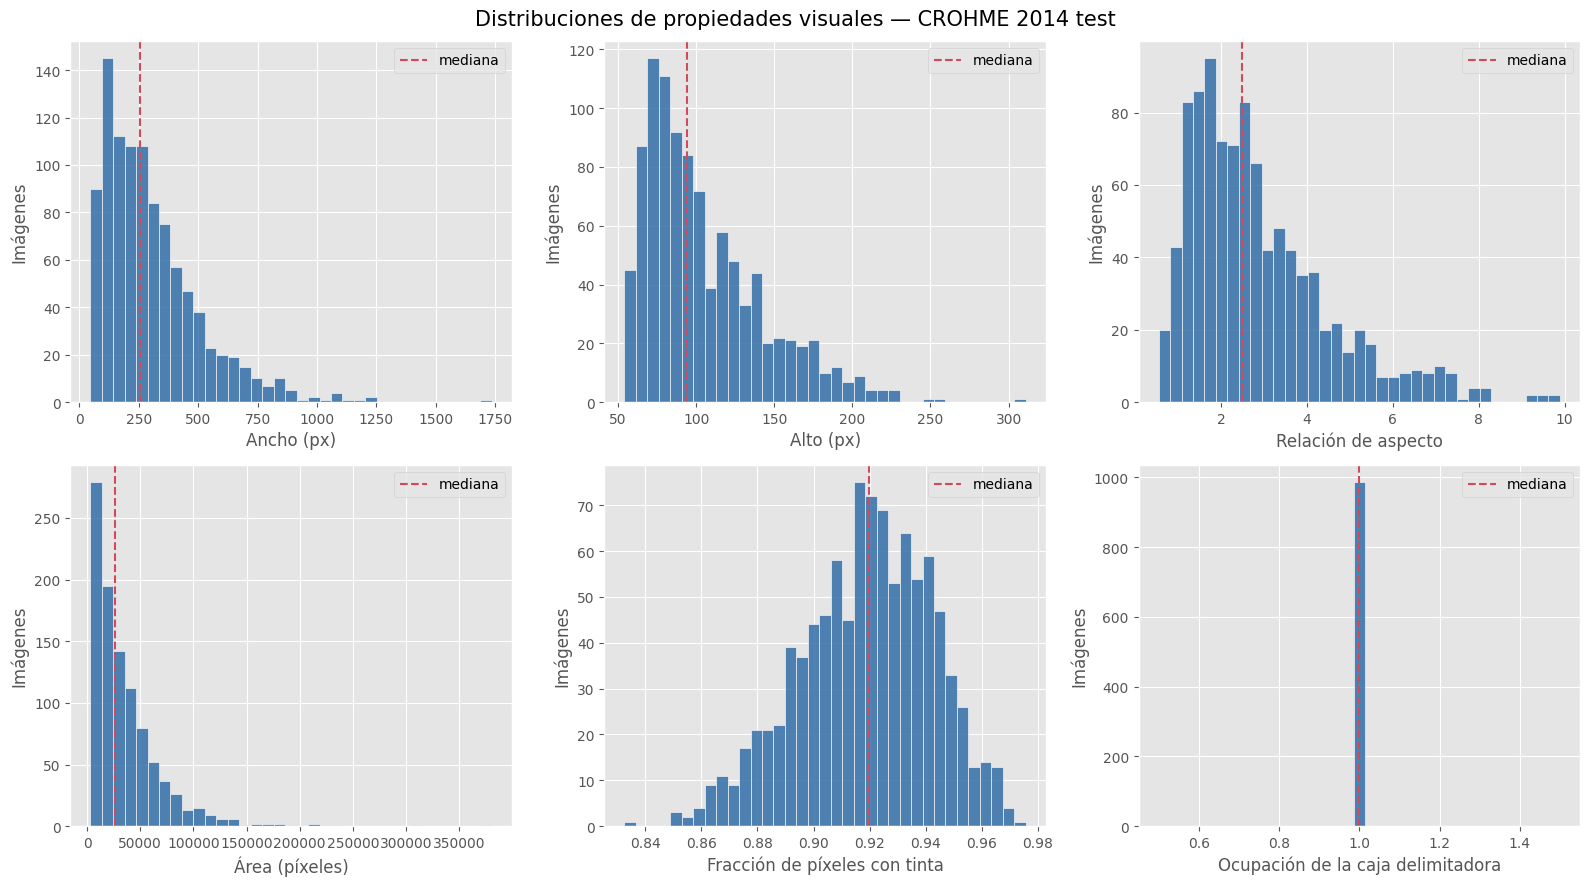

In [7]:
fig, ejes = plt.subplots(2, 3, figsize=(16, 9))
graficas = [
    ("ancho", "Ancho (px)", 35),
    ("alto", "Alto (px)", 35),
    ("relacion_aspecto", "Relación de aspecto", 35),
    ("pixeles", "Área (píxeles)", 35),
    ("fraccion_tinta", "Fracción de píxeles con tinta", 35),
    ("ocupacion_bbox", "Ocupación de la caja delimitadora", 35),
]
for eje, (columna, etiqueta, bins) in zip(ejes.flat, graficas):
    datos = df[columna].dropna()
    eje.hist(datos, bins=bins, color="#326fa8", alpha=0.85, edgecolor="white")
    eje.axvline(datos.median(), color="#d1495b", linestyle="--", label="mediana")
    eje.set(xlabel=etiqueta, ylabel="Imágenes")
    eje.legend()
fig.suptitle("Distribuciones de propiedades visuales — CROHME 2014 test", fontsize=15)
fig.tight_layout()
plt.show()


In [8]:
def mascara_iqr(serie: pd.Series, factor: float = 1.5) -> pd.Series:
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (serie < q1 - factor * iqr) | (serie > q3 + factor * iqr)

for columna in ["ancho", "alto", "relacion_aspecto", "pixeles", "fraccion_tinta"]:
    df[f"atipico_{columna}"] = mascara_iqr(df[columna])

resumen_atipicos = pd.Series(
    {col: int(df[f"atipico_{col}"].sum()) for col in
     ["ancho", "alto", "relacion_aspecto", "pixeles", "fraccion_tinta"]},
    name="cantidad_atípica",
).to_frame()
display(resumen_atipicos)

display(
    df.nlargest(10, "pixeles")[
        ["id", "ancho", "alto", "relacion_aspecto", "pixeles", "n_tokens", "latex"]
    ]
)


,cantidad_atípica
ancho,35
alto,24
relacion_aspecto,39
pixeles,50
fraccion_tinta,4


,id,ancho,alto,relacion_aspecto,pixeles,n_tokens,latex
410,505_em_51,1224,311,3.935691,380664,204,| x ^ { \frac { 1 } { n } } - c ^ { \frac { 1 } { n } } | = \frac { | x ^ { \frac { 1 } { n } } - c ^ { \frac { 1 } { n } } | | x ^ { \f...
394,504_em_35,1734,178,9.741573,308652,29,( x \times x ) \times ( x \times x ) \times ( x \times x ) = x \times x \times x \times x \times x \times x
37,20_em_37,1096,211,5.194313,231256,66,\frac { 3 \times 3 ^ { 2 } } { 2 } + \frac { 5 \times ( - 5 ) ^ { 2 } } { 2 } = \frac { 3 \times v _ { 1 } ^ { 2 } } { 2 } + \frac { 5 \...
339,501_em_14,1179,194,6.077320,228726,47,2 \pi n ! e = 2 \pi n ! + \frac { 2 \pi n ! } { 2 } + \frac { 2 \pi n ! } { 3 ! } + \frac { 2 \pi n ! } { 4 ! } + \ldots
539,514_em_325,1130,191,5.916230,215830,19,\frac { x \times x \times x \times x \times x } { x \times x \times x }
748,RIT_2014_168,1095,195,5.615385,213525,50,2 \pi n ! e = 2 \pi n ! + \frac { 2 \pi n ! } { 2 } + \frac { 2 \pi n ! } { 3 ! } + \frac { 2 \pi n ^ { ! } } { 4 ! } + \ldots
343,501_em_18,926,206,4.495146,190756,75,\frac { 2 G M r - 2 r ^ { 3 } \pm r \sqrt { 4 r ^ { 4 } - 8 G M r ^ { 2 } + 4 G ^ { 2 } M ^ { 2 } - 4 r ^ { 4 } + 4 G M r ^ { 2 } } } { ...
543,514_em_329,1105,168,6.577381,185640,40,( 1 - 1 ) ^ { 3 } + 1 ^ { 3 } < \frac { 1 } { 4 } 2 ^ { 4 } < 1 ^ { 3 } + 2 ^ { 3 }
402,504_em_43,1103,161,6.850932,177583,29,2 \times 3 \times 4 \times x ^ { 2 } \times x \times y \times y ^ { 3 } \times z \times z ^ { 2 }
171,29_em_173,825,209,3.947368,172425,40,\frac { x ^ { 2 } + 1 3 x + 4 0 } { 2 x ^ { 3 } + 2 7 x ^ { 2 } + 1 1 1 x + 1 4 0 }


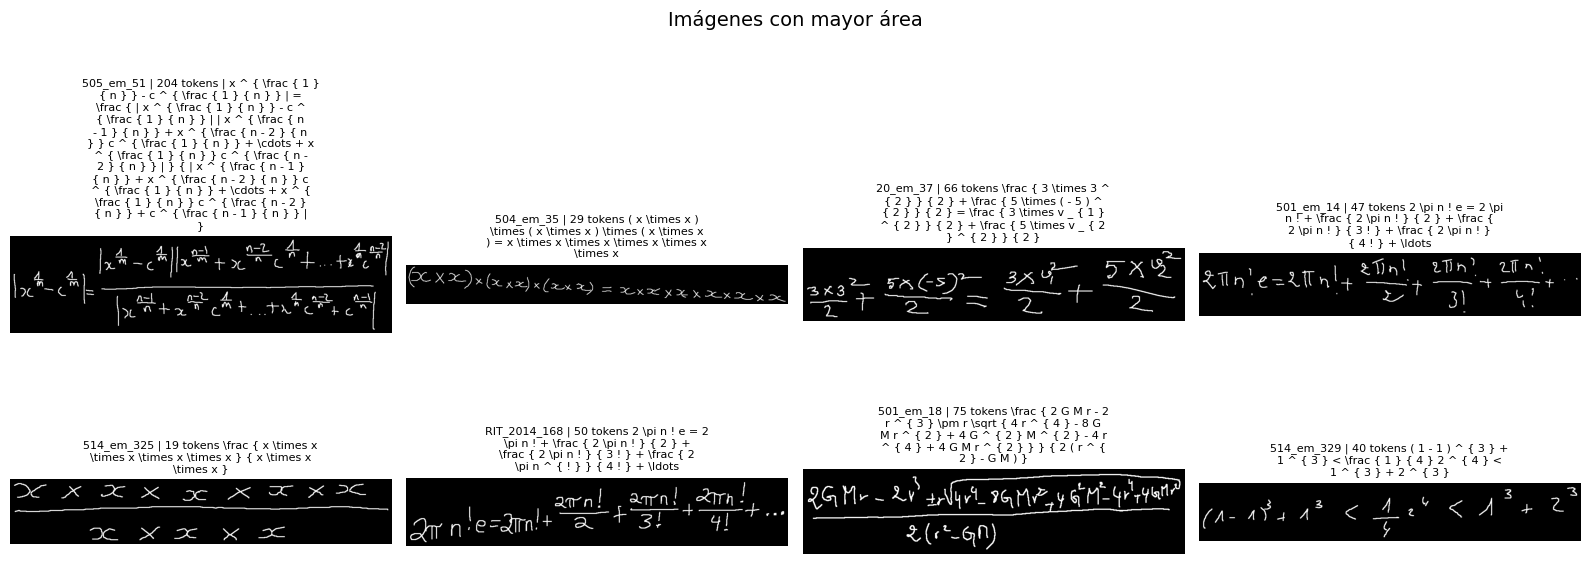

In [9]:
def mostrar_muestras(tabla: pd.DataFrame, titulo: str, n: int = 8) -> None:
    muestra = tabla.head(n)
    if muestra.empty:
        print("No hay muestras para mostrar.")
        return
    columnas = 4
    filas = math.ceil(len(muestra) / columnas)
    fig, ejes = plt.subplots(filas, columnas, figsize=(16, 3.5 * filas))
    ejes = np.atleast_1d(ejes).ravel()
    for eje, (_, fila) in zip(ejes, muestra.iterrows()):
        with Image.open(fila["ruta_imagen"]) as imagen:
            eje.imshow(imagen.convert("L"), cmap="gray", vmin=0, vmax=255)
        etiqueta = textwrap.fill(f"{fila['id']} | {fila['n_tokens']} tokens\n{fila['latex']}", 42)
        eje.set_title(etiqueta, fontsize=8)
        eje.axis("off")
    for eje in ejes[len(muestra):]:
        eje.axis("off")
    fig.suptitle(titulo, fontsize=14)
    fig.tight_layout()
    plt.show()

mostrar_muestras(
    df.sort_values("pixeles", ascending=False),
    "Imágenes con mayor área",
)


## 3. Exploración de ecuaciones y tokens LaTeX

Se estudian tanto la longitud de las secuencias como la distribución del vocabulario. Una concentración alta en pocos tokens y una cola larga de tokens raros son relevantes para el entrenamiento: afectan el desbalance de clases y la dificultad para reconocer símbolos poco frecuentes.


In [10]:
frecuencias = Counter(token for tokens in df["tokens"] for token in tokens)
total_tokens = sum(frecuencias.values())
tabla_tokens = (
    pd.DataFrame(frecuencias.items(), columns=["token", "frecuencia"])
    .sort_values(["frecuencia", "token"], ascending=[False, True])
    .reset_index(drop=True)
)
tabla_tokens["proporcion"] = tabla_tokens["frecuencia"] / total_tokens
tabla_tokens["porcentaje"] = 100 * tabla_tokens["proporcion"]
tabla_tokens["frecuencia_acumulada"] = tabla_tokens["frecuencia"].cumsum()
tabla_tokens["proporcion_acumulada"] = tabla_tokens["frecuencia_acumulada"] / total_tokens
tabla_tokens["n_ecuaciones"] = tabla_tokens["token"].map(
    lambda token: int(df["tokens"].map(lambda xs: token in xs).sum())
)
tabla_tokens["proporcion_ecuaciones"] = tabla_tokens["n_ecuaciones"] / len(df)

resumen_tokens = pd.Series(
    {
        "ecuaciones": len(df),
        "tokens totales": total_tokens,
        "vocabulario": len(frecuencias),
        "tokens únicos (hapax)": sum(f == 1 for f in frecuencias.values()),
        "tokens con frecuencia <= 5": sum(f <= 5 for f in frecuencias.values()),
        "media tokens/ecuación": df["n_tokens"].mean(),
        "mediana tokens/ecuación": df["n_tokens"].median(),
        "máximo tokens/ecuación": df["n_tokens"].max(),
    },
    name="valor",
).to_frame()
display(resumen_tokens.round(3))
display(tabla_tokens.head(30).style.format(
    {"proporcion": "{:.4%}", "porcentaje": "{:.3f}", "proporcion_acumulada": "{:.2%}",
     "proporcion_ecuaciones": "{:.2%}"}
))


,valor
ecuaciones,986.000
tokens totales,15897.000
vocabulario,108.000
tokens únicos (hapax),1.000
tokens con frecuencia <= 5,6.000
media tokens/ecuación,16.123
mediana tokens/ecuación,13.000
máximo tokens/ecuación,204.000


,token,frecuencia,proporcion,porcentaje,frecuencia_acumulada,proporcion_acumulada,n_ecuaciones,proporcion_ecuaciones
0,{,2297,14.4493%,14.449,2297,14.45%,687,69.68%
1,},2297,14.4493%,14.449,4594,28.90%,687,69.68%
2,1,727,4.5732%,4.573,5321,33.47%,379,38.44%
3,2,717,4.5103%,4.510,6038,37.98%,352,35.70%
4,_,630,3.9630%,3.963,6668,41.95%,275,27.89%
5,+,626,3.9378%,3.938,7294,45.88%,327,33.16%
6,^,607,3.8183%,3.818,7901,49.70%,292,29.61%
7,x,593,3.7303%,3.730,8494,53.43%,248,25.15%
8,-,488,3.0698%,3.070,8982,56.50%,287,29.11%
9,(,458,2.8810%,2.881,9440,59.38%,247,25.05%


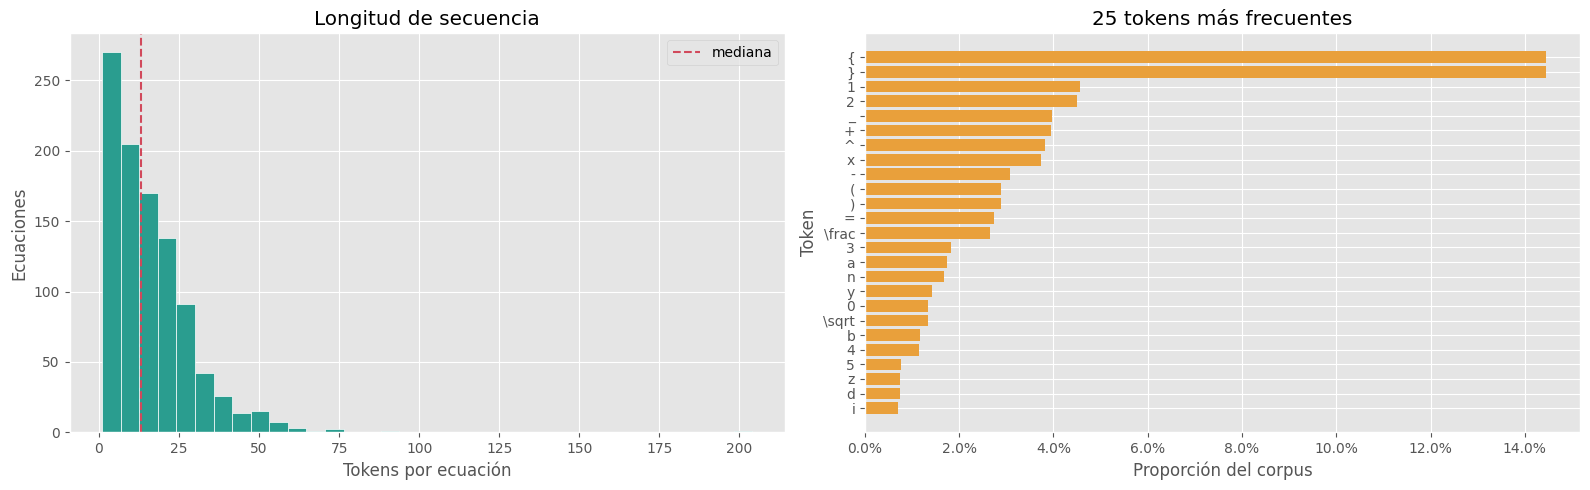

,id,n_tokens,n_caracteres,latex
410,505_em_51,204,481,| x ^ { \frac { 1 } { n } } - c ^ { \frac { 1 } { n } } | = \frac { | x ^ { \frac { 1 } { n } } - c ^ { \frac { 1 } { n } } | | x ^ { \f...
337,501_em_12,91,205,\frac { T _ { H } ^ { \frac { f } { 2 } } V _ { 2 } } { T _ { H } ^ { \frac { f } { 2 } } V _ { 1 } } = \frac { T _ { C } ^ { \frac { f ...
917,RIT_2014_38,76,171,- \frac { 1 1 } { 1 2 } y _ { n + 1 } + \frac { 5 } { 3 } y _ { n } - \frac { 1 } { 2 } y _ { n - 1 } - \frac { 1 } { 3 } y _ { n - 2 } ...
343,501_em_18,75,159,\frac { 2 G M r - 2 r ^ { 3 } \pm r \sqrt { 4 r ^ { 4 } - 8 G M r ^ { 2 } + 4 G ^ { 2 } M ^ { 2 } - 4 r ^ { 4 } + 4 G M r ^ { 2 } } } { ...
37,20_em_37,66,167,\frac { 3 \times 3 ^ { 2 } } { 2 } + \frac { 5 \times ( - 5 ) ^ { 2 } } { 2 } = \frac { 3 \times v _ { 1 } ^ { 2 } } { 2 } + \frac { 5 \...
361,502_em_11,63,146,( 1 - 2 ^ { - s } ) ( 1 + \frac { 1 } { 2 ^ { s } } + \frac { 1 } { 3 ^ { s } } + \frac { 1 } { 4 ^ { s } } + \frac { 1 } { 5 ^ { s } } ...
17,18_em_2,60,124,C _ { 1 } y _ { 1 } ^ { ( n - 1 ) } + C _ { 2 } y _ { 2 } ^ { ( n - 1 ) } + \ldots + C _ { n } y _ { n } ^ { ( n - 1 ) } = 0
951,RIT_2014_69,59,145,\sqrt { \frac { 1 + x } { 1 - x } } = \sqrt { \frac { 1 + x } { 1 + x } \frac { 1 + x } { 1 - x } } = \frac { 1 + x } { \sqrt { 1 - x ^ ...
344,501_em_19,58,137,\tan ( 5 x ) = \frac { 5 \tan ( x ) - 1 0 \tan ^ { 3 } ( x ) + \tan ^ { 5 } ( x ) } { 1 - 1 0 \tan ^ { 2 } ( x ) + 5 \tan ^ { 4 } ( x ) }
796,RIT_2014_210,57,157,\frac { 1 } { 4 } + \frac { 2 } { 5 } = \frac { 1 \times 5 } { 4 \times 5 } + \frac { 2 \times 4 } { 5 \times 4 } = \frac { 5 } { 2 0 } ...


In [11]:
fig, ejes = plt.subplots(1, 2, figsize=(16, 5))

ejes[0].hist(df["n_tokens"], bins=35, color="#2a9d8f", edgecolor="white")
ejes[0].axvline(df["n_tokens"].median(), color="#d1495b", linestyle="--", label="mediana")
ejes[0].set(xlabel="Tokens por ecuación", ylabel="Ecuaciones", title="Longitud de secuencia")
ejes[0].legend()

top = tabla_tokens.head(25).sort_values("proporcion")
ejes[1].barh(top["token"], top["proporcion"], color="#e9a03b")
ejes[1].xaxis.set_major_formatter(PercentFormatter(1))
ejes[1].set(xlabel="Proporción del corpus", ylabel="Token", title="25 tokens más frecuentes")

fig.tight_layout()
plt.show()

display(
    df.nlargest(15, "n_tokens")[["id", "n_tokens", "n_caracteres", "latex"]]
)


,cobertura_objetivo,tipos_necesarios,proporcion_vocabulario
0,50%,8,7.41%
1,80%,22,20.37%
2,90%,41,37.96%
3,95%,58,53.70%
4,99%,87,80.56%


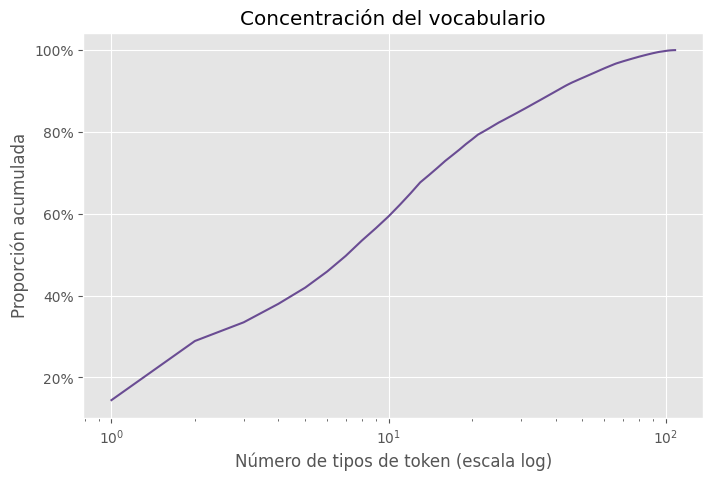

In [12]:
# Curva de cobertura: ¿cuántos tipos explican la mayor parte de las apariciones?
umbrales = [0.50, 0.80, 0.90, 0.95, 0.99]
cobertura = []
for umbral in umbrales:
    n_tipos = int((tabla_tokens["proporcion_acumulada"] < umbral).sum() + 1)
    cobertura.append(
        {
            "cobertura_objetivo": umbral,
            "tipos_necesarios": n_tipos,
            "proporcion_vocabulario": n_tipos / len(tabla_tokens),
        }
    )
cobertura = pd.DataFrame(cobertura)
display(cobertura.style.format(
    {"cobertura_objetivo": "{:.0%}", "proporcion_vocabulario": "{:.2%}"}
))

fig, eje = plt.subplots(figsize=(8, 5))
eje.plot(
    np.arange(1, len(tabla_tokens) + 1),
    tabla_tokens["proporcion_acumulada"],
    color="#6a4c93",
)
eje.set_xscale("log")
eje.yaxis.set_major_formatter(PercentFormatter(1))
eje.set(
    xlabel="Número de tipos de token (escala log)",
    ylabel="Proporción acumulada",
    title="Concentración del vocabulario",
)
plt.show()


,categoria,frecuencia,tipos,proporcion
4,llaves,4594,2,28.90%
3,letras,3025,44,19.03%
2,dígitos,2607,10,16.40%
0,comandos LaTeX,1483,29,9.33%
6,otros,1258,3,7.91%
5,operadores,1242,7,7.81%
1,delimitadores/puntuación,1168,7,7.35%
7,relaciones,520,6,3.27%


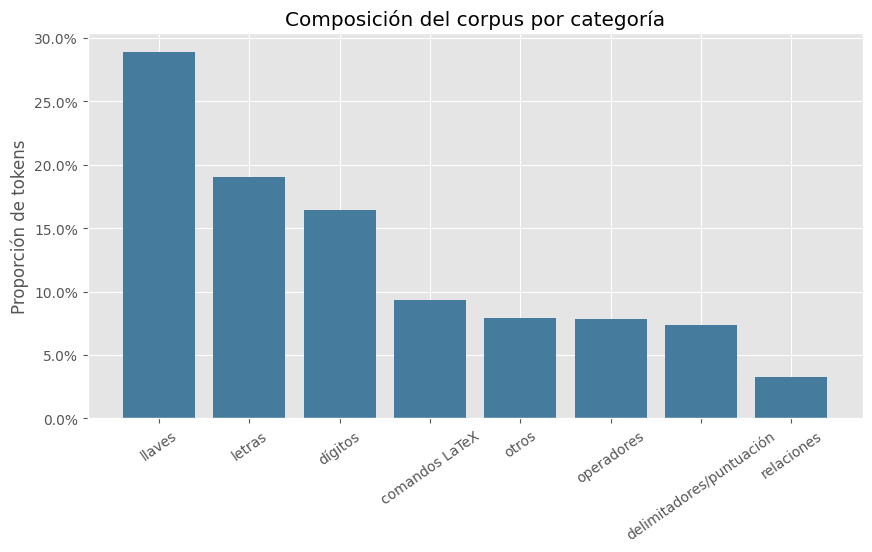

In [13]:
def categoria_token(token: str) -> str:
    if token in {"{", "}"}:
        return "llaves"
    if token in {"=", "<", ">", "\\leq", "\\geq", "\\neq", "\\approx", "\\sim"}:
        return "relaciones"
    if token in {"+", "-", "\\times", "\\div", "\\pm", "\\cdot", "/", "*"}:
        return "operadores"
    if token.startswith("\\"):
        return "comandos LaTeX"
    if token in {"(", ")", "[", "]", "|", ",", ".", ":", ";"}:
        return "delimitadores/puntuación"
    if token.isdigit():
        return "dígitos"
    if re.fullmatch(r"[A-Za-z]+", token):
        return "letras"
    return "otros"

tabla_tokens["categoria"] = tabla_tokens["token"].map(categoria_token)
categorias = (
    tabla_tokens.groupby("categoria", as_index=False)
    .agg(frecuencia=("frecuencia", "sum"), tipos=("token", "count"))
)
categorias["proporcion"] = categorias["frecuencia"] / total_tokens
categorias = categorias.sort_values("frecuencia", ascending=False)

display(categorias.style.format({"proporcion": "{:.2%}"}))

fig, eje = plt.subplots(figsize=(10, 5))
eje.bar(categorias["categoria"], categorias["proporcion"], color="#457b9d")
eje.yaxis.set_major_formatter(PercentFormatter(1))
eje.set(ylabel="Proporción de tokens", xlabel="", title="Composición del corpus por categoría")
eje.tick_params(axis="x", rotation=35)
plt.show()


In [14]:
def balance_llaves(tokens):
    nivel = 0
    maximo = 0
    cierre_anticipado = False
    for token in tokens:
        if token == "{":
            nivel += 1
            maximo = max(maximo, nivel)
        elif token == "}":
            nivel -= 1
            if nivel < 0:
                cierre_anticipado = True
    return (nivel == 0 and not cierre_anticipado), nivel, maximo

estructura = df["tokens"].map(balance_llaves)
df["llaves_balanceadas"] = estructura.map(lambda x: x[0])
df["balance_final_llaves"] = estructura.map(lambda x: x[1])
df["profundidad_max_llaves"] = estructura.map(lambda x: x[2])
df["n_comandos"] = df["tokens"].map(lambda xs: sum(t.startswith("\\") for t in xs))
df["n_tokens_raros"] = df["tokens"].map(
    lambda xs: sum(frecuencias[t] <= 5 for t in xs)
)
df["proporcion_tokens_raros"] = (
    df["n_tokens_raros"] / df["n_tokens"].replace(0, np.nan)
)

comandos = tabla_tokens[tabla_tokens["token"].str.startswith("\\")].copy()
display(
    pd.Series(
        {
            "ecuaciones con llaves no balanceadas": int((~df["llaves_balanceadas"]).sum()),
            "profundidad máxima observada": int(df["profundidad_max_llaves"].max()),
            "comandos LaTeX distintos": len(comandos),
            "apariciones de comandos": int(comandos["frecuencia"].sum()),
            "ecuaciones con algún token raro": int(df["n_tokens_raros"].gt(0).sum()),
        },
        name="valor",
    ).to_frame()
)
display(comandos.head(30)[["token", "frecuencia", "proporcion", "n_ecuaciones"]].style.format(
    {"proporcion": "{:.3%}"}
))
display(
    df.loc[~df["llaves_balanceadas"],
           ["id", "balance_final_llaves", "profundidad_max_llaves", "latex"]]
)


,valor
ecuaciones con llaves no balanceadas,0
profundidad máxima observada,4
comandos LaTeX distintos,36
apariciones de comandos,1654
ecuaciones con algún token raro,10


,token,frecuencia,proporcion,n_ecuaciones
12,\frac,423,2.661%,266
18,\sqrt,214,1.346%,125
26,\sin,95,0.598%,62
35,\sum,74,0.465%,56
36,\times,72,0.453%,23
37,\cos,70,0.440%,47
38,\pi,68,0.428%,36
39,\int,67,0.421%,49
41,\theta,64,0.403%,30
45,\infty,50,0.315%,37


,id,balance_final_llaves,profundidad_max_llaves,latex


In [15]:
# Ecuaciones repetidas: pueden representar distintas escrituras de la misma expresión.
duplicados_latex = (
    df.groupby("latex", as_index=False)
    .agg(n_muestras=("id", "size"), ids=("id", lambda s: list(s)))
    .query("n_muestras > 1")
    .sort_values("n_muestras", ascending=False)
)
print(f"Expresiones distintas repetidas: {len(duplicados_latex)}")
print(f"Muestras dentro de grupos repetidos: {duplicados_latex['n_muestras'].sum()}")
display(duplicados_latex.head(20))


Expresiones distintas repetidas: 13
Muestras dentro de grupos repetidos: 26


,latex,n_muestras,ids
77,- | y | \leq y \leq | y |,2,"[RIT_2014_289, RIT_2014_294]"
111,1 8 z,2,"[RIT_2014_122, RIT_2014_176]"
119,1 m,2,"[RIT_2014_132, RIT_2014_187]"
256,P a,2,"[29_em_151, 517_em_404]"
295,\beta = 1,2,"[502_em_10, 502_em_9]"
358,\frac { 1 } { 9 },2,"[RIT_2014_154, RIT_2014_99]"
576,"\sigma _ { a } , \sigma _ { m }",2,"[RIT_2014_160, RIT_2014_205]"
624,\sqrt { 5 0 },2,"[501_em_1, 501_em_5]"
641,\sqrt { a b } = \sqrt { a } \sqrt { b },2,"[510_em_106, 510_em_107]"
805,k g,2,"[512_em_296, 514_em_330]"


## 4. Relación entre complejidad visual y complejidad simbólica

La longitud de la secuencia no determina por sí sola el tamaño de la imagen: influyen el estilo del escritor, la disposición bidimensional y el contenido. Aun así, sus asociaciones sirven para diseñar límites de tamaño, batches y estrategias de padding.


,n_tokens,n_caracteres,ancho,alto,relacion_aspecto,pixeles,fraccion_tinta,ocupacion_bbox,profundidad_max_llaves,n_comandos
n_tokens,1.000,0.972,0.784,0.738,0.526,0.846,0.404,NaN,0.642,0.398
n_caracteres,0.972,1.000,0.789,0.751,0.526,0.855,0.392,NaN,0.634,0.573
ancho,0.784,0.789,1.000,0.587,0.866,0.948,0.593,NaN,0.281,0.350
alto,0.738,0.751,0.587,1.000,0.141,0.803,0.634,NaN,0.642,0.493
relacion_aspecto,0.526,0.526,0.866,0.141,1.000,0.670,0.341,NaN,-0.023,0.147
pixeles,0.846,0.855,0.948,0.803,0.670,1.000,0.675,NaN,0.441,0.439
fraccion_tinta,0.404,0.392,0.593,0.634,0.341,0.675,1.000,NaN,0.281,0.166
ocupacion_bbox,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
profundidad_max_llaves,0.642,0.634,0.281,0.642,-0.023,0.441,0.281,NaN,1.000,0.370
n_comandos,0.398,0.573,0.350,0.493,0.147,0.439,0.166,NaN,0.370,1.000


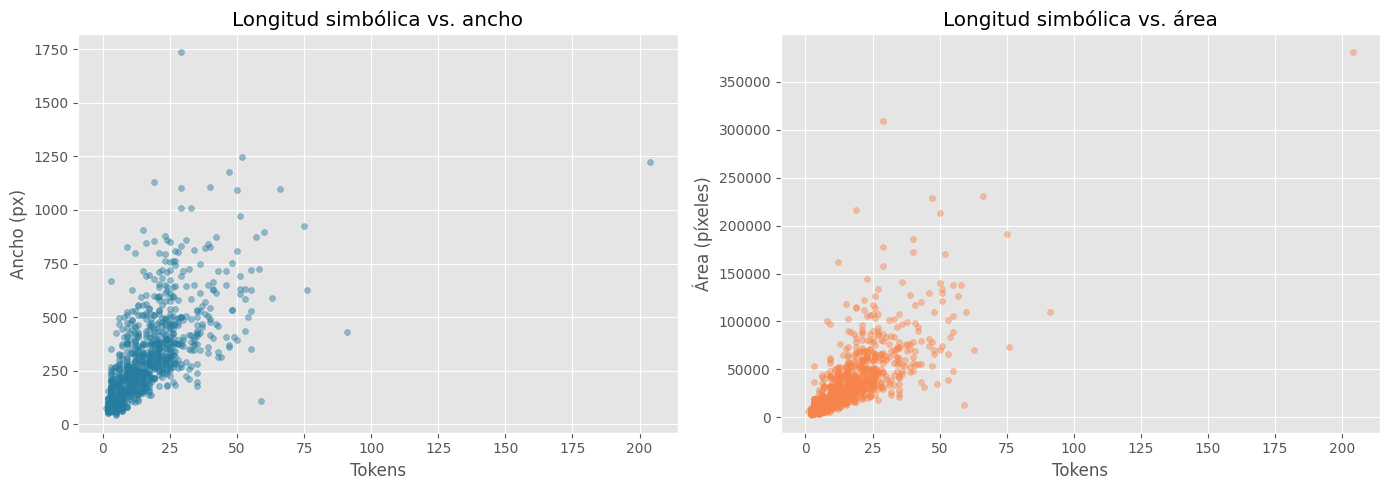

In [16]:
variables = [
    "n_tokens", "n_caracteres", "ancho", "alto", "relacion_aspecto",
    "pixeles", "fraccion_tinta", "ocupacion_bbox",
    "profundidad_max_llaves", "n_comandos",
]
correlaciones = df[variables].corr(method="spearman")
display(correlaciones.round(3))

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
ejes[0].scatter(df["n_tokens"], df["ancho"], alpha=0.45, s=18, color="#277da1")
ejes[0].set(xlabel="Tokens", ylabel="Ancho (px)", title="Longitud simbólica vs. ancho")
ejes[1].scatter(df["n_tokens"], df["pixeles"], alpha=0.45, s=18, color="#f9844a")
ejes[1].set(xlabel="Tokens", ylabel="Área (píxeles)", title="Longitud simbólica vs. área")
fig.tight_layout()
plt.show()


In [17]:
# Segmentación descriptiva de complejidad mediante cuartiles.
# duplicates='drop' evita fallos si dos puntos de corte coinciden.
df["grupo_longitud"] = pd.qcut(
    df["n_tokens"],
    q=4,
    labels=["Q1 corta", "Q2", "Q3", "Q4 larga"],
    duplicates="drop",
)
resumen_grupos = (
    df.groupby("grupo_longitud", observed=True)
    .agg(
        muestras=("id", "size"),
        tokens_mediana=("n_tokens", "median"),
        ancho_mediana=("ancho", "median"),
        alto_mediana=("alto", "median"),
        pixeles_mediana=("pixeles", "median"),
        tinta_mediana=("fraccion_tinta", "median"),
        comandos_media=("n_comandos", "mean"),
        profundidad_media=("profundidad_max_llaves", "mean"),
    )
)
display(resumen_grupos.round(3))


,muestras,tokens_mediana,ancho_mediana,alto_mediana,pixeles_mediana,tinta_mediana,comandos_media,profundidad_media
grupo_longitud,,,,,,,,
Q1 corta,270,4.0,115.5,71.0,8081.0,0.908,0.719,0.300
Q2,241,10.0,222.0,87.0,19440.0,0.916,1.207,0.739
Q3,252,18.0,319.5,115.0,37258.5,0.928,1.988,1.159
Q4 larga,223,30.0,460.0,128.0,60198.0,0.931,2.996,1.408


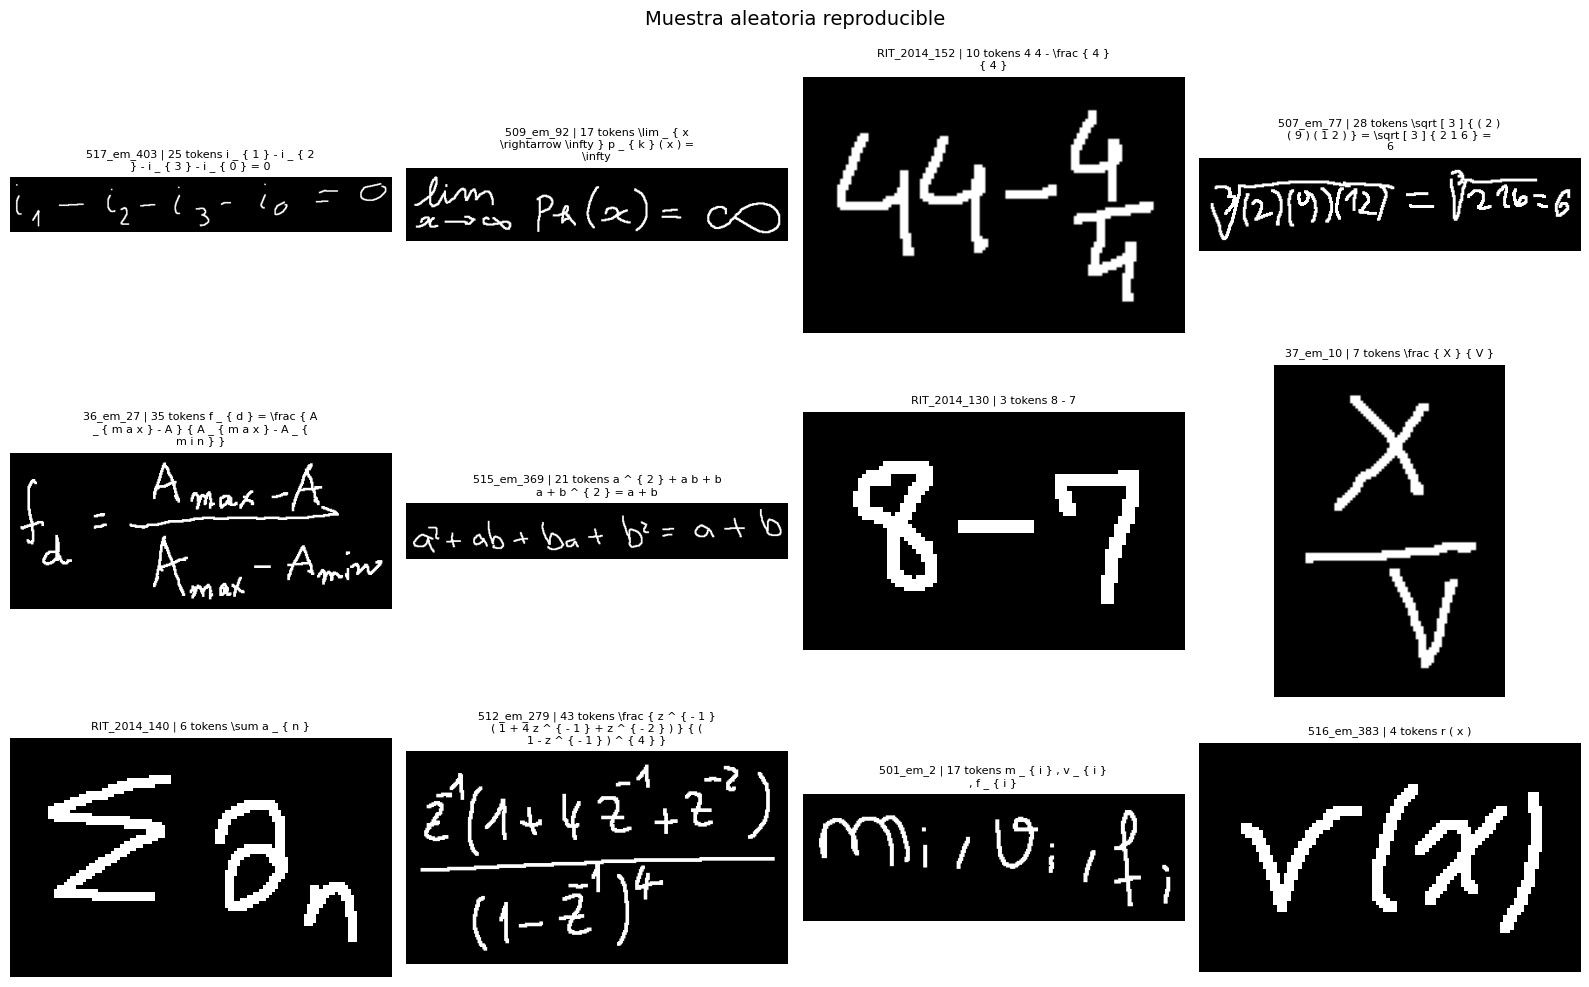

In [18]:
muestra_aleatoria = df[df["imagen_existe"]].sample(
    n=min(12, int(df["imagen_existe"].sum())),
    random_state=RANDOM_SEED,
)
mostrar_muestras(muestra_aleatoria, "Muestra aleatoria reproducible", n=12)


## 5. Exportación y conclusiones operativas

Se exportan:

- \`muestras_crohme_2014.csv\`: una fila por pareja imagen–ecuación, sin la lista interna de tokens;
- \`frecuencias_tokens.csv\`: frecuencia, proporción, cobertura y presencia por ecuación;
- \`resumen_eda.json\`: indicadores clave para documentación o etapas posteriores.

Los resultados permiten fijar políticas de preprocesamiento basadas en percentiles, preservar ejemplos extremos para pruebas y vigilar tokens escasos al construir vocabularios.


In [19]:
columnas_exportar = [
    c for c in df.columns
    if c not in {"tokens", "ruta_imagen"}
]
df[columnas_exportar].to_csv(
    RESULTADOS_DIR / "muestras_crohme_2014_modelo1.csv",
    index=False,
    encoding="utf-8",
)
tabla_tokens.to_csv(
    RESULTADOS_DIR / "frecuencias_tokens_modelo1.csv",
    index=False,
    encoding="utf-8",
)

def valor_json(valor):
    if pd.isna(valor):
        return None
    if isinstance(valor, (np.integer,)):
        return int(valor)
    if isinstance(valor, (np.floating,)):
        return float(valor)
    return valor

resumen_final = {
    "dataset": "CROHME 2014 test - Modelo1",
    "ruta_dataset": str(DATA_DIR.relative_to(RAIZ)),
    "n_captions": int(len(captions)),
    "n_imagenes_bmp": int(len(imagenes)),
    "n_pares_validos": int(df["imagen_existe"].sum()),
    "n_imagenes_con_error": int(meta_img["error_imagen"].notna().sum()),
    "n_captions_sin_imagen": int(len(ids_caption - ids_imagen)),
    "n_imagenes_sin_caption": int(len(ids_imagen - ids_caption)),
    "total_tokens": int(total_tokens),
    "tamano_vocabulario": int(len(frecuencias)),
    "tokens_hapax": int(sum(f == 1 for f in frecuencias.values())),
    "tokens_frecuencia_hasta_5": int(sum(f <= 5 for f in frecuencias.values())),
    "tokens_por_ecuacion": {
        "media": valor_json(df["n_tokens"].mean()),
        "mediana": valor_json(df["n_tokens"].median()),
        "p95": valor_json(df["n_tokens"].quantile(0.95)),
        "maximo": valor_json(df["n_tokens"].max()),
    },
    "imagen": {
        "ancho_mediana": valor_json(df["ancho"].median()),
        "ancho_p95": valor_json(df["ancho"].quantile(0.95)),
        "alto_mediana": valor_json(df["alto"].median()),
        "alto_p95": valor_json(df["alto"].quantile(0.95)),
        "relacion_aspecto_mediana": valor_json(df["relacion_aspecto"].median()),
        "fraccion_tinta_mediana": valor_json(df["fraccion_tinta"].median()),
    },
    "estructura": {
        "ecuaciones_llaves_no_balanceadas": int((~df["llaves_balanceadas"]).sum()),
        "profundidad_maxima_llaves": int(df["profundidad_max_llaves"].max()),
        "ecuaciones_con_tokens_raros": int(df["n_tokens_raros"].gt(0).sum()),
        "expresiones_distintas_repetidas": int(len(duplicados_latex)),
    },
    "top_20_tokens": [
        {
            "token": fila.token,
            "frecuencia": int(fila.frecuencia),
            "proporcion": float(fila.proporcion),
        }
        for fila in tabla_tokens.head(20).itertuples()
    ],
}

with (RESULTADOS_DIR / "resumen_eda_modelo1.json").open("w", encoding="utf-8") as archivo:
    json.dump(resumen_final, archivo, ensure_ascii=False, indent=2)

print("Archivos generados:")
for ruta in sorted(RESULTADOS_DIR.glob("*")):
    print(f"- {ruta.name} ({ruta.stat().st_size:,} bytes)")


Archivos generados:
- .gitkeep (1 bytes)
- frecuencias_tokens.csv (11,964 bytes)
- frecuencias_tokens_modelo1.csv (11,763 bytes)
- muestras_crohme_2014.csv (236,057 bytes)
- muestras_crohme_2014_modelo1.csv (251,841 bytes)
- resumen_eda.json (3,015 bytes)
- resumen_eda_modelo1.json (3,028 bytes)


### Lista de comprobación para interpretar los resultados

1. Confirmar que no existan pares faltantes ni imágenes corruptas.
2. Usar percentiles (por ejemplo P95/P99) antes de elegir límites de ancho, alto o longitud; no decidir sólo con máximos.
3. Revisar visualmente los extremos antes de considerarlos errores.
4. No eliminar tokens raros sin comprobar su significado: pueden ser símbolos matemáticos válidos y relevantes.
5. Si se define un vocabulario reducido, cuantificar la cobertura y reservar explícitamente un token desconocido.
6. Mantener el *split* de test separado de cualquier ajuste de vocabulario, normalización aprendida o selección de hiperparámetros.
